# Analyze the outputs of K-fold cross validation for tuning the beta parameter

First we need to load some basic datasets. We may use them later

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Data path: /home/donglaiyang/Documents/Georgia-Tech/Research/thermal-model/Amundsen-thermal-output-Yang/thermal-training-data/Thwaites-PIG/training/gridded/
Parameter path: /home/donglaiyang/Documents/Georgia-Tech/Research/thermal-model/data/post-processing-parameters.csv
Output path: /data-archive/ASE-inference/train-validate-test/
Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized_train: (256, 256, 1, 937)
Shape of Ns_standardized_train: (256, 256, 1, 937)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


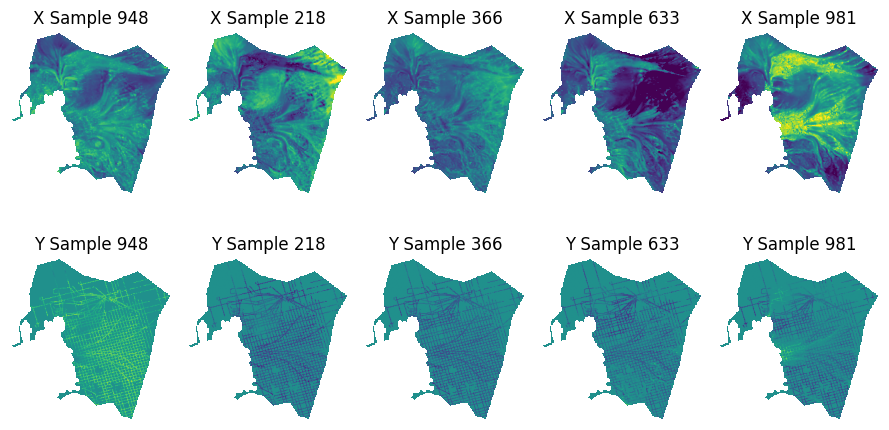

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model
from src.ice import compute_pmp

%load_ext autoreload
%autoreload 2

data_path       = os.getenv('RAW_DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
output_path     = os.getenv('INFERENCE_READY_DATA_PATH')
print("Data path:", data_path)
print("Parameter path:", param_path)
print("Output path:", output_path)
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized_train = np.load(output_path + XY_train_filename)['Eb_train']
Ns_standardized_train = np.load(output_path + XY_train_filename)['Ns_train']
Eb_standardized_valid = np.load(output_path + XY_valid_filename)['Eb_validation']
Ns_standardized_valid = np.load(output_path + XY_valid_filename)['Ns_validation']
Eb_standardized_test  = np.load(output_path + XY_test_filename)['Eb_test']
Ns_standardized_test  = np.load(output_path + XY_test_filename)['Ns_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

# compute pmp
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
pmp = compute_pmp(H)


# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of Ns_standardized_train:', Ns_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)

# -----------------------------------------------------------------------------------------------------------------------------
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
Ns_standardized_all = np.concatenate([Ns_standardized_train, 
                                      Ns_standardized_valid, 
                                      Ns_standardized_test], 
                                      axis=3)
md.load_sim_data(Eb_standardized_all, Ns_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

# load pmp
md.pmp = pmp

PCA model saved to self.pca_x and self.pca_y.
Shape of XY_train: (937, 65)
Shape of XY_validation: (0, 65)
Shape of XY_test: (105, 65)
GMM training completed in 1.30 seconds.


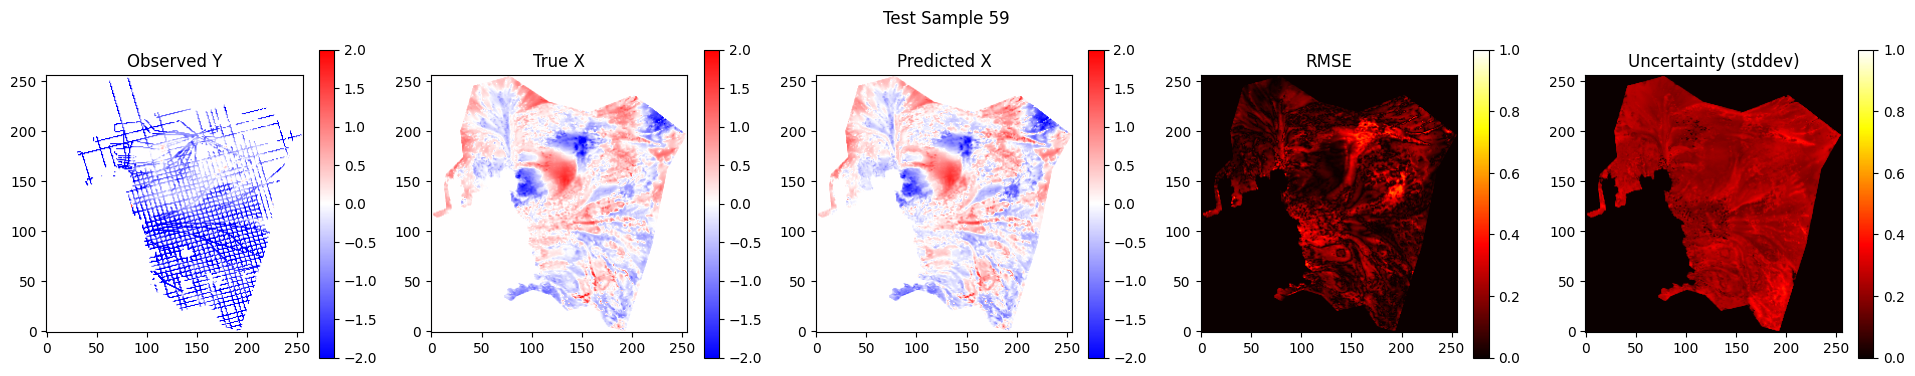

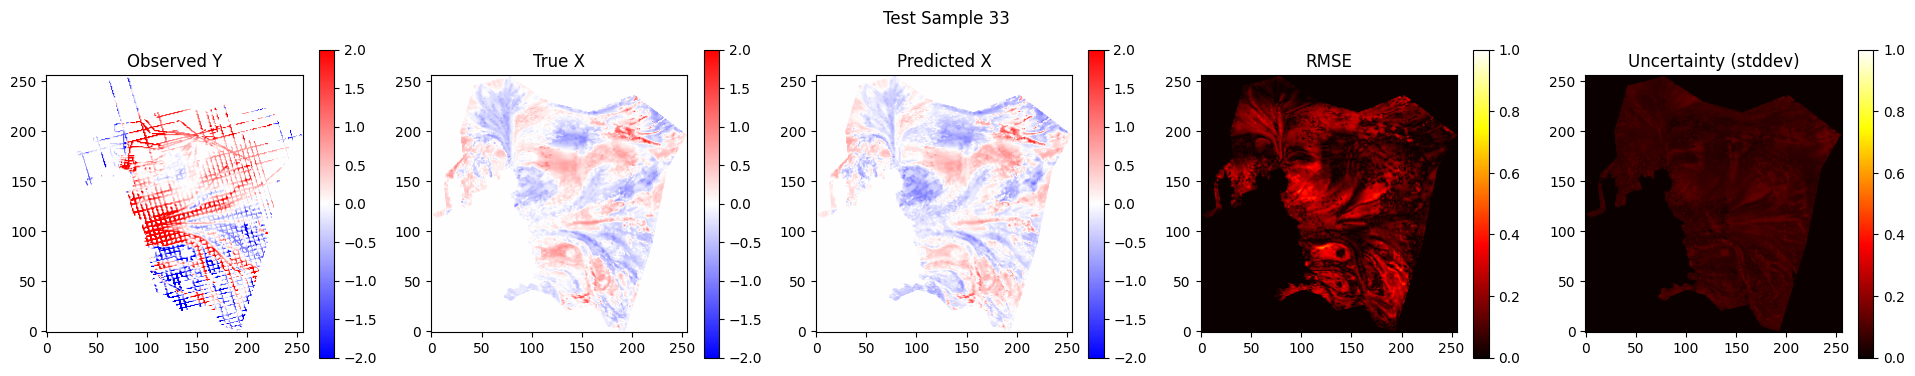

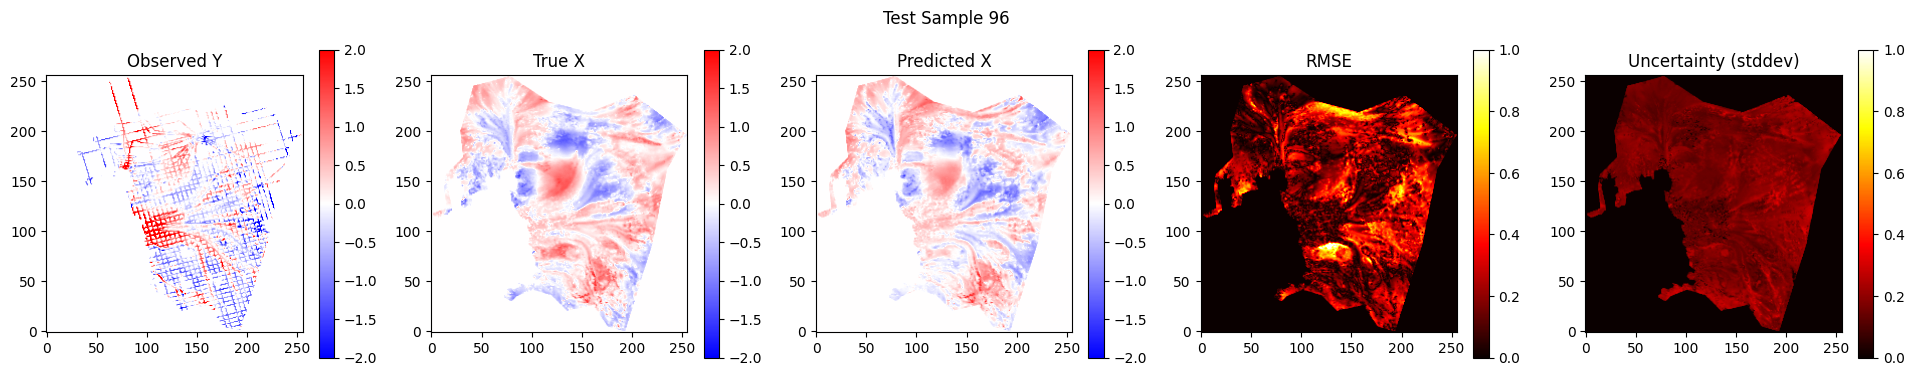

In [36]:
from src.validation import bayesian_information_criterion

# reduce dim with PCA. 
md.find_reduction_model_pca(n_component_x=50, n_component_y=15)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PCA
md.load_split_data(X_train=Eb_standardized_train, Y_train=Ns_standardized_train,
                   X_validation=Eb_standardized_valid, Y_validation=Ns_standardized_valid,
                   X_test=Eb_standardized_test, Y_test=Ns_standardized_test)


# based on the BIC sweep plot
n_optimal = 20
md.train_gmm_XY(n_components=n_optimal)
md.plot_gmm_samples_pca(n_samples=3)

# Load the posterior models

Loaded samples from /data-archive/ASE-inference/posteriors/models/mcmc_run_beta_1.0_kfold_0.pt
HMC Sampling Complete. Extracted shape: (3000, 50)
Sample: 3000/3000
Eb samples saved to /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_1.0_kfold_0_ori.npy and /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_1.0_kfold_0_norm.npy
Finished analyzing posterior samples for beta = 1.0 kfold = 0
--- HMC Sampling Metrics ---
Total Samples Drawn: 3000
Mean ESS across all dimensions: 1601.73
Minimum ESS (Worst mixing dimension): 922.28
Maximum ESS (Best mixing dimension): 2404.11
Post-Burn-in Mean ESS: 997.91
Post-Burn-in Min ESS: 561.33


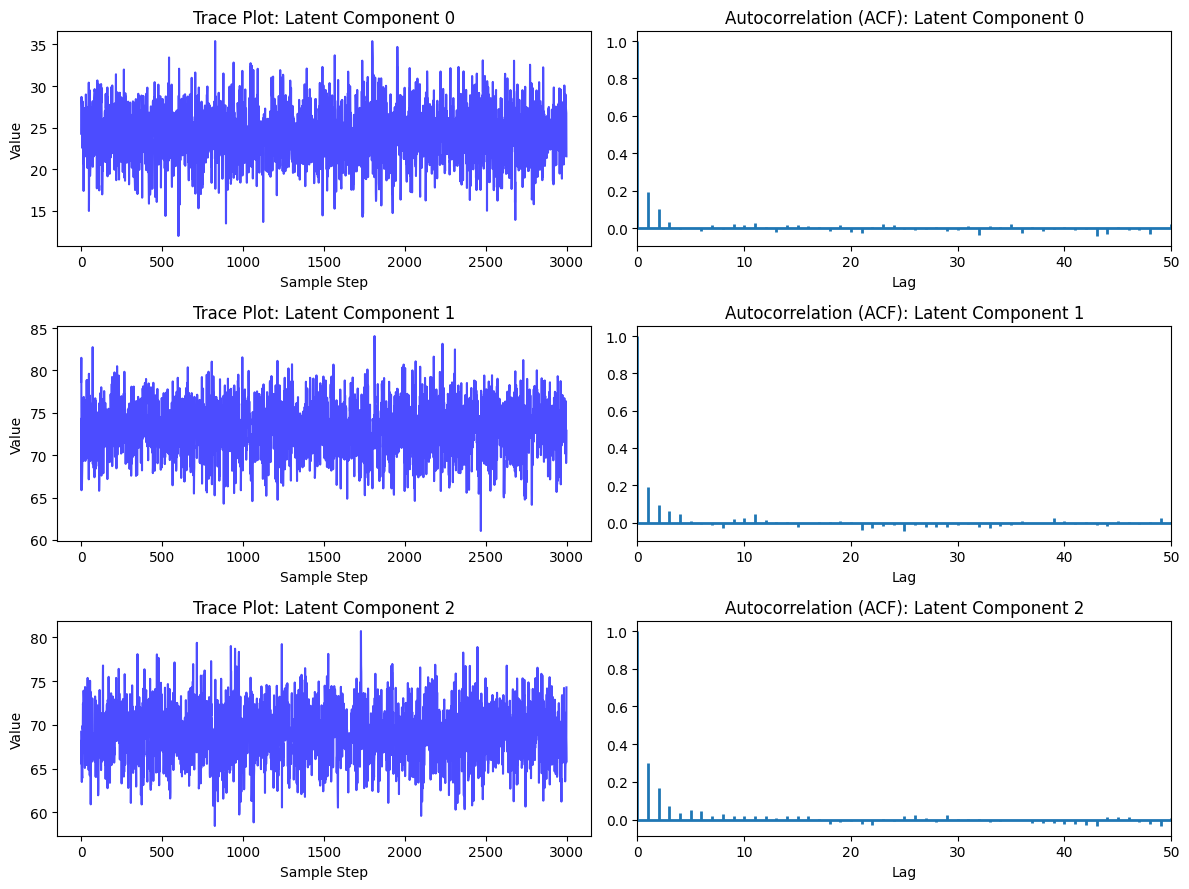

Loaded samples from /data-archive/ASE-inference/posteriors/models/mcmc_run_beta_2.0_kfold_0.pt
HMC Sampling Complete. Extracted shape: (3000, 50)
Sample: 3000/3000
Eb samples saved to /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_2.0_kfold_0_ori.npy and /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_2.0_kfold_0_norm.npy
Finished analyzing posterior samples for beta = 2.0 kfold = 0
--- HMC Sampling Metrics ---
Total Samples Drawn: 3000
Mean ESS across all dimensions: 2297.65
Minimum ESS (Worst mixing dimension): 1303.01
Maximum ESS (Best mixing dimension): 3152.43
Post-Burn-in Mean ESS: 1532.58
Post-Burn-in Min ESS: 942.77


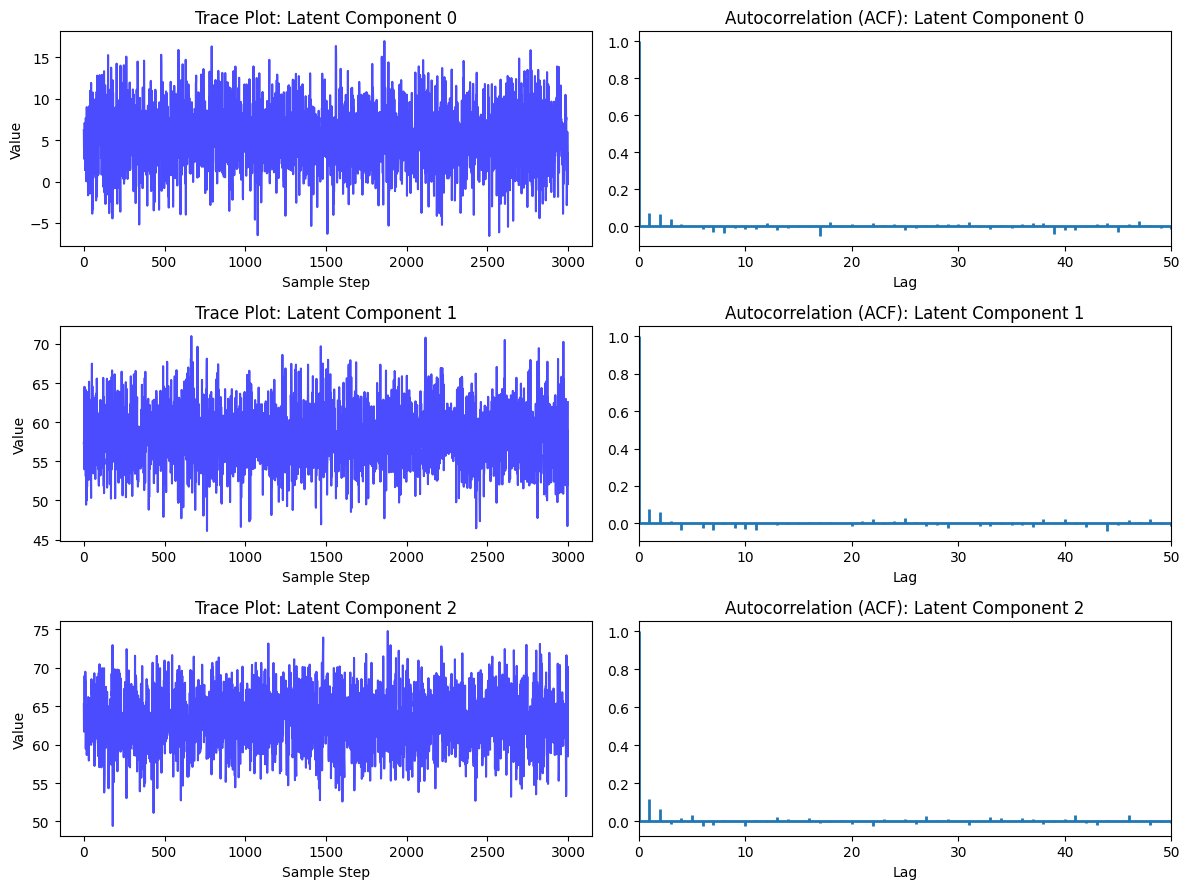

Loaded samples from /data-archive/ASE-inference/posteriors/models/mcmc_run_beta_3.0_kfold_0.pt
HMC Sampling Complete. Extracted shape: (3000, 50)
Sample: 3000/3000
Eb samples saved to /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_3.0_kfold_0_ori.npy and /data-archive/ASE-inference/posteriors/samples/Eb_samples_beta_3.0_kfold_0_norm.npy
Finished analyzing posterior samples for beta = 3.0 kfold = 0
--- HMC Sampling Metrics ---
Total Samples Drawn: 3000
Mean ESS across all dimensions: 2832.22
Minimum ESS (Worst mixing dimension): 2080.56
Maximum ESS (Best mixing dimension): 3778.18
Post-Burn-in Mean ESS: 1811.65
Post-Burn-in Min ESS: 1353.70


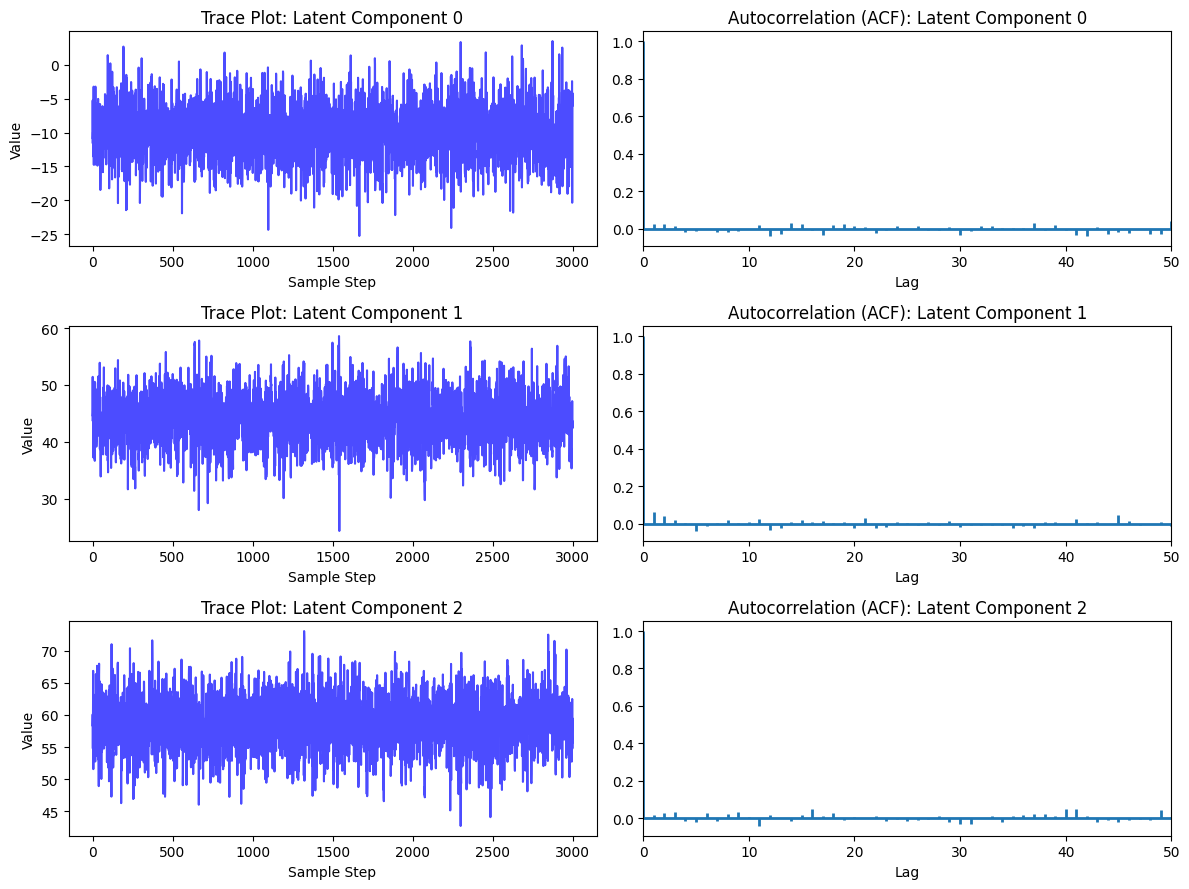

In [61]:
import copy

posterior_md_path = "/data-archive/ASE-inference/posteriors/models/"
posterior_samples_path = "/data-archive/ASE-inference/posteriors/samples/"
md_name_pattern = "mcmc_run_beta_{}_kfold_{}.pt"

# load all the posterior models for different beta and kfold
beta_list = [1.0, 2.0, 3.0]
kfold_list = [0]

# md_pristine = copy.deepcopy(md) 

import numpy.dtypes
import torch.serialization

torch.serialization.add_safe_globals([
    np._core.multiarray._reconstruct,
    np.ndarray,
    np.dtype,
    np.dtypes.Float64DType,      # ← the new one causing this error
    np._core.multiarray.scalar,
])

for beta in beta_list:
    for kfold in kfold_list:
        md_name = md_name_pattern.format(beta, kfold)
        md_path = posterior_md_path + md_name
        samples_path = posterior_samples_path + f"Eb_samples_beta_{beta}_kfold_{kfold}.npy"

        md_copy = copy.deepcopy(md)
        md_copy.analyze_posterior_samples(beta=beta, 
                                          beta_w=0.01, 
                                          loading=True,
                                          loadname=md_path,
                                          savename=samples_path)
        print("Finished analyzing posterior samples for beta =", beta, "kfold =", kfold)

        md_copy.posterior_quality_check()


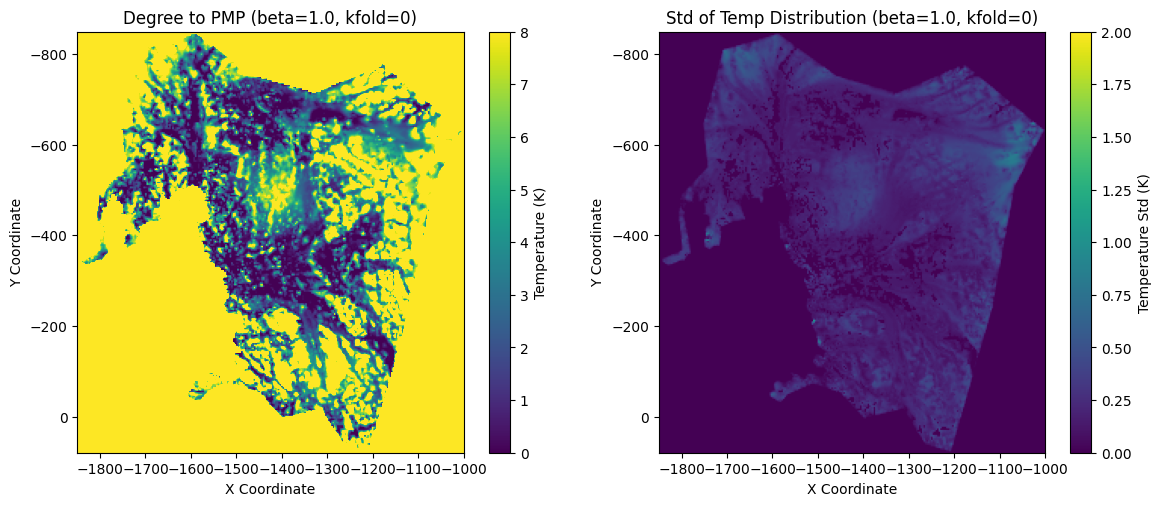

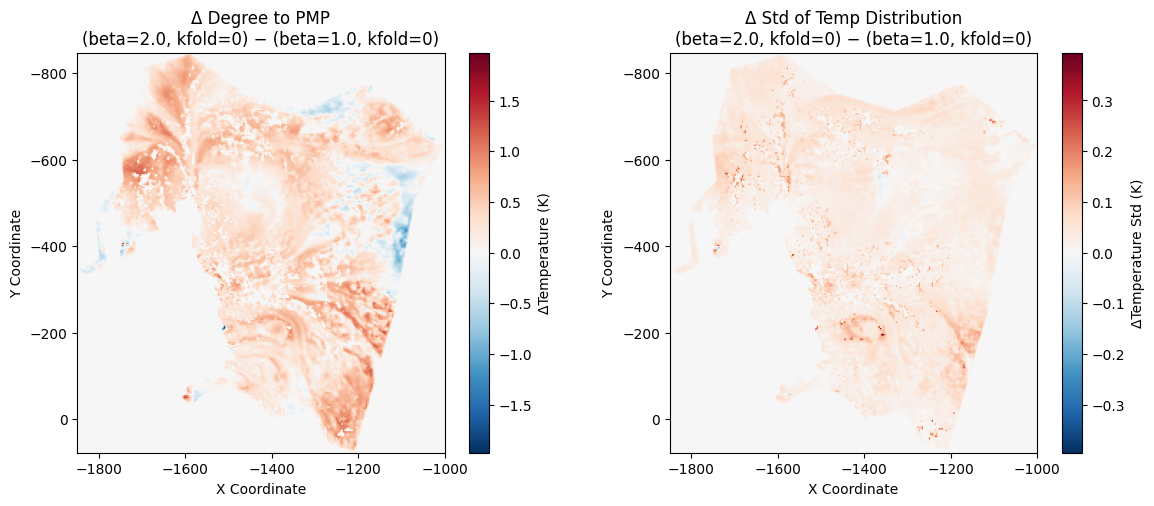

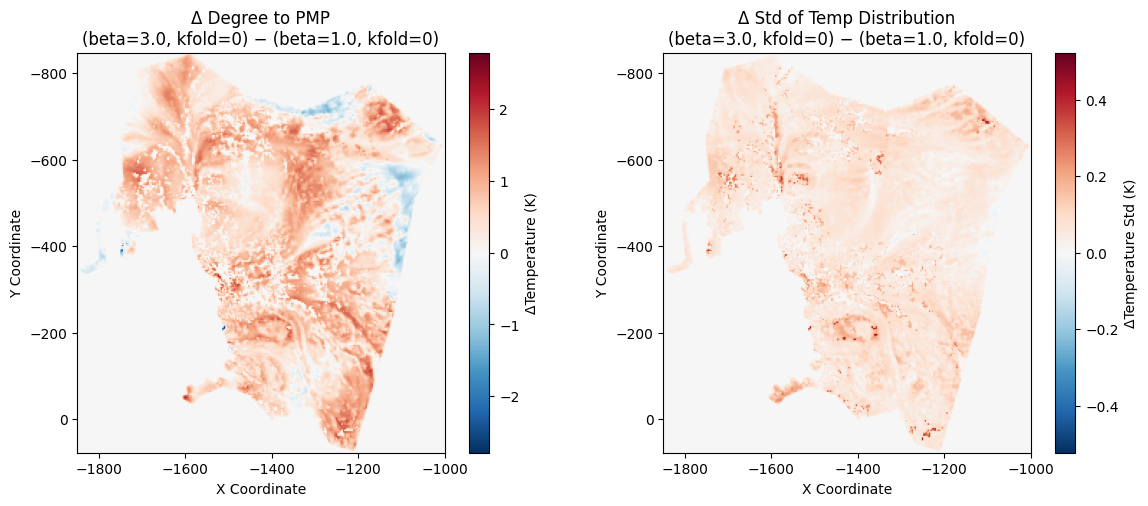

In [60]:
from src.ice import enthalpy_to_temperature

# Storage for reference (first iteration)
ref_Tb_mean = None
ref_Tb_std  = None
ref_beta    = None
ref_kfold   = None

for beta in beta_list:
    for kfold in kfold_list:
        samples_path = posterior_samples_path + f"Eb_samples_beta_{beta}_kfold_{kfold}_ori.npy"
        Eb_samples  = np.load(samples_path)

        # ── Convert to temperature ─────────────────────────────────────────
        Tb_samples  = np.zeros_like(Eb_samples)
        Tpmp_flat   = md.pmp.flatten()
        num_samples = Eb_samples.shape[0]

        for i in range(num_samples):
            Eb_i   = torch.from_numpy(Eb_samples[i])
            Tpmp_i = torch.from_numpy(Tpmp_flat) if isinstance(Tpmp_flat, np.ndarray) else Tpmp_flat
            Tb_samples[i] = enthalpy_to_temperature(Eb_i, Tpmp_i).numpy()

        Tb_std  = np.std(Tb_samples,  axis=0).reshape(md.nx, md.ny)
        Tb_mean = np.mean(Tb_samples, axis=0).reshape(md.nx, md.ny)
        deg_to_pmp = md.pmp.reshape(md.nx, md.ny) - Tb_mean

        # ── First iteration: store as reference ───────────────────────────
        is_first = (ref_Tb_mean is None)
        if is_first:
            ref_Tb_mean = Tb_mean.copy()
            ref_Tb_std  = Tb_std.copy()
            ref_beta    = beta
            ref_kfold   = kfold

        # ── Plot ──────────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        if is_first:
            # Absolute maps for the reference run
            im0 = axes[0].imshow(deg_to_pmp, extent=extent, origin='lower', vmin=0, vmax=8)
            axes[0].set_title(f"Degree to PMP (beta={beta}, kfold={kfold})")
            fig.colorbar(im0, ax=axes[0], label='Temperature (K)')

            im1 = axes[1].imshow(Tb_std, extent=extent, origin='lower', vmin=0, vmax=2)
            axes[1].set_title(f"Std of Temp Distribution (beta={beta}, kfold={kfold})")
            fig.colorbar(im1, ax=axes[1], label='Temperature Std (K)')

        else:
            # Difference maps relative to the first run
            diff_mean = deg_to_pmp - (md.pmp.reshape(md.nx, md.ny) - ref_Tb_mean)
            diff_std  = Tb_std - ref_Tb_std

            # Symmetric colormap centered at zero
            abs_max_mean = np.nanmax(np.abs(diff_mean))
            abs_max_std  = np.nanmax(np.abs(diff_std))

            im0 = axes[0].imshow(diff_mean, extent=extent, origin='lower',
                                 cmap='RdBu_r', vmin=-abs_max_mean, vmax=abs_max_mean)
            axes[0].set_title(
                f"Δ Degree to PMP\n(beta={beta}, kfold={kfold}) − (beta={ref_beta}, kfold={ref_kfold})"
            )
            fig.colorbar(im0, ax=axes[0], label='ΔTemperature (K)')

            im1 = axes[1].imshow(diff_std, extent=extent, origin='lower',
                                 cmap='RdBu_r', vmin=-abs_max_std, vmax=abs_max_std)
            axes[1].set_title(
                f"Δ Std of Temp Distribution\n(beta={beta}, kfold={kfold}) − (beta={ref_beta}, kfold={ref_kfold})"
            )
            fig.colorbar(im1, ax=axes[1], label='ΔTemperature Std (K)')

        for ax in axes:
            ax.set_xlabel("X Coordinate")
            ax.set_ylabel("Y Coordinate")

        plt.tight_layout()
        plt.show()
